Three types of scalar time dependence:
- function
- string
- array

Can reperesent objects of the form
$$
  A(t) = \sum_k f_k(t)A_k,
$$

where the 
$f_k(t)$ are time-dependent scalar functions, and the 
$A_k$ are constant `Qobj` objects. The list then looks like

<pre>
  <code> [A0, [A1, f1], [A2, f2], ...] </code> = $0
</pre>

In [ ]:
import numpy as onp
import qutip as qt

size = 4
t = 1.0
a = qt.destroy(size)
ad = qt.create(size)
n = qt.num(size)
Id = qt.qeye(size)

constant_form = qt.QobjEvo([n])

def cos_t(t):
  return onp.cos(t)

function_form = n + (a + ad) * qt.coefficient(cos_t)

class callable_time_dependence:
  def __init__(self, add):
    self.add = add

  def __call__(self, t, args):
    return self.add + onp.cos(t)


callable_form = qt.QobjEvo([n, [a + ad, callable_time_dependence(2)]])

string_form = qt.QobjEvo([n, [a + ad, "cos(t)"]])


tlist = onp.linspace(0, 10, 101)
values = onp.cos(tlist)

array_form = n + (a + ad) * qt.coefficient(values, tlist=tlist)

display(constant_form(2))
display(function_form(2))
display(callable_form(2))
display(string_form(2))
display(array_form(2))

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dia, isherm=True
Qobj data =
[[0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 2. 0.]
 [0. 0. 0. 3.]]

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dia, isherm=True
Qobj data =
[[ 0.         -0.41614684  0.          0.        ]
 [-0.41614684  1.         -0.5885205   0.        ]
 [ 0.         -0.5885205   2.         -0.72078746]
 [ 0.          0.         -0.72078746  3.        ]]

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dia, isherm=True
Qobj data =
[[0.         1.58385316 0.         0.        ]
 [1.58385316 1.         2.23990662 0.        ]
 [0.         2.23990662 2.         2.74331415]
 [0.         0.         2.74331415 3.        ]]

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dia, isherm=True
Qobj data =
[[ 0.         -0.41614684  0.          0.        ]
 [-0.41614684  1.         -0.5885205   0.        ]
 [ 0.         -0.5885205   2.         -0.72078746]
 [ 0.          0.         -0.72078746  3.        ]]

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dia, isherm=True
Qobj data =
[[ 0.         -0.41614684  0.          0.        ]
 [-0.41614684  1.         -0.5885205   0.        ]
 [ 0.         -0.5885205   2.         -0.72078746]
 [ 0.          0.         -0.72078746  3.        ]]

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from qutip import Bloch, about, basis, mesolve, sigmam, sigmax, sigmay, sigmaz

%matplotlib inline


Hamiltonian for the qubit - flips the state of the qubit represented by the pauli matrix $\sigma_x$
$$
H = \frac{\Delta}{2}\sigma_x,
$$
and add a collapse operator that describes the dissipation of energy from the qubit to the environment
$$
C=\sqrt{g}\sigma_z,
$$
where $g$ is the dissipation coefficient

In [51]:
# coefficients
Δ = 2 * np.pi
g = 0.25

σ_x, σ_y, σ_z = sigmax(), sigmay(), sigmaz()

# hamiltonian
H = Δ / 2.0 * σ_x

# list of collapse operators
C = np.sqrt(g) * σ_z
c_ops = [C]

# initial state
psi0 = basis(2, 0)

# times
ts = np.linspace(0, 20, 191)

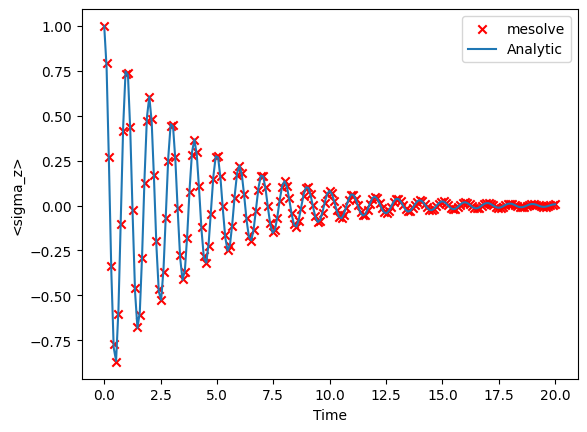

In [52]:
res = mesolve(H, psi0, ts, c_ops, e_ops=[σ_z])
sz_analytic = np.cos(2 * np.pi * ts) * np.exp(-ts * g)

plt.scatter(ts, res.expect[0], c="r", marker="x", label="mesolve")
plt.plot(ts, sz_analytic, label="Analytic")
plt.xlabel("Time")
plt.ylabel("<sigma_z>")
plt.legend();

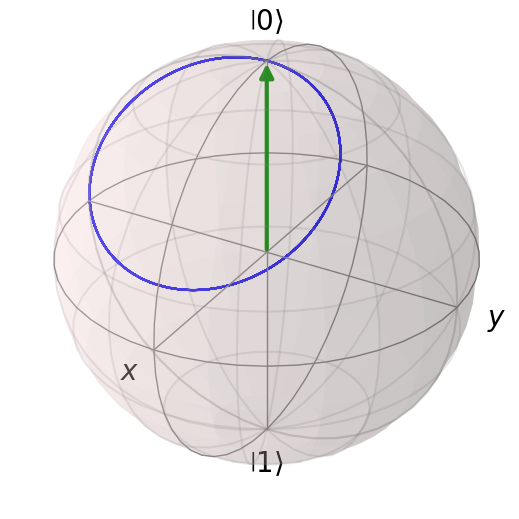

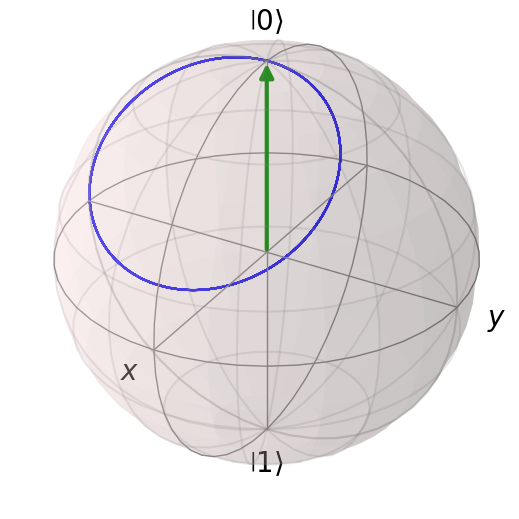

In [59]:
# Angle
θ: float = 0.2 * np.pi

# Hamiltonian
H = Δ * (np.cos(θ) * σ_z + np.sin(θ) * σ_x)

# Obtain Time Evolution
ts = np.linspace(0, 5, 1000)
result = mesolve(H, psi0, ts, [], e_ops=[σ_x, σ_y, σ_z])

# Extract expectation values for pauli matrices
exp_sx_circ, exp_sy_circ, exp_sz_circ = result.expect
exp_sx_circ, exp_sy_circ, exp_sz_circ = (
    np.array(exp_sx_circ),
    np.array(exp_sy_circ),
    np.array(exp_sz_circ),
)

# Create Bloch sphere plot
sphere = Bloch()
sphere.add_points([exp_sx_circ, exp_sy_circ, exp_sz_circ], meth="l")
sphere.add_states(psi0)
sphere.show();

### Qubit Dephasing

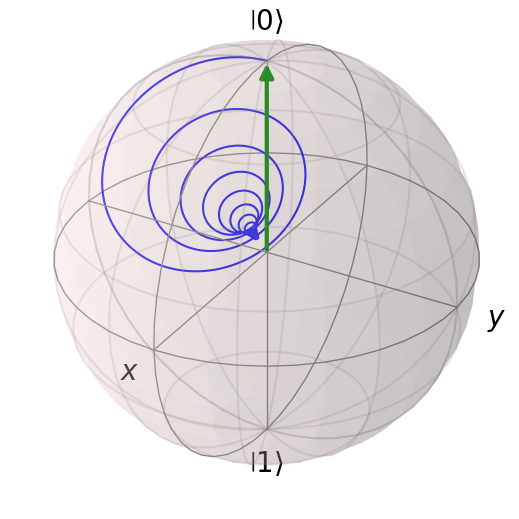

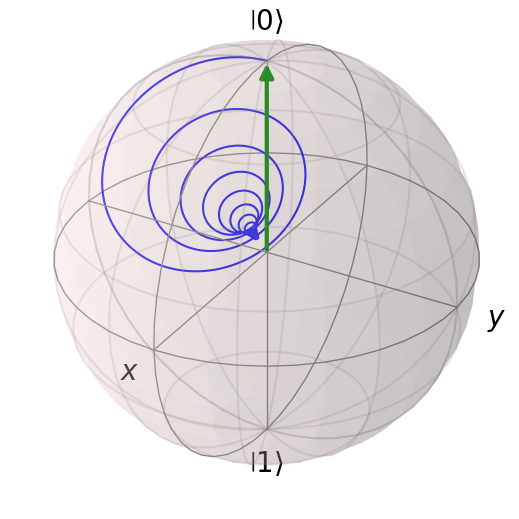

In [ ]:
gamma_phase = 0.5
c_ops = [np.sqrt(gamma_phase) * sigmaz()]

# solve dynamics
result = mesolve(H, psi0, ts, c_ops, e_ops=[sigmax(), sigmay(), sigmaz()])
exp_sx_dephase, exp_sy_dephase, exp_sz_dephase = result.expect
exp_sx_dephase, exp_sy_dephase, exp_sz_dephase = (
    np.array(exp_sx_dephase),
    np.array(exp_sy_dephase),
    np.array(exp_sz_dephase),
)

# Create Bloch sphere plot
sphere = Bloch()
sphere.add_points([exp_sx_dephase, exp_sy_dephase, exp_sz_dephase], meth="l")
sphere.add_states(psi0)
sphere.show()

### Qubit Relaxation

[-60, 30]


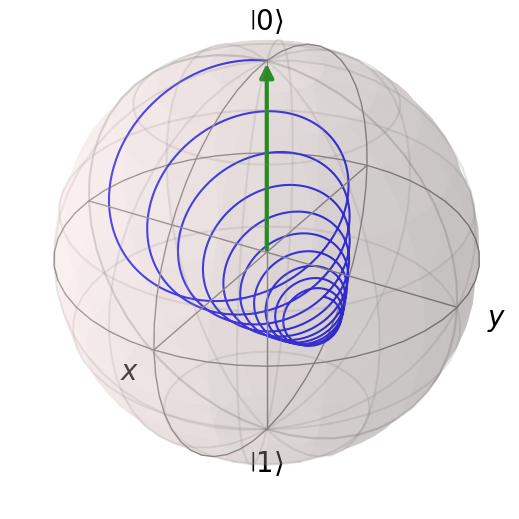

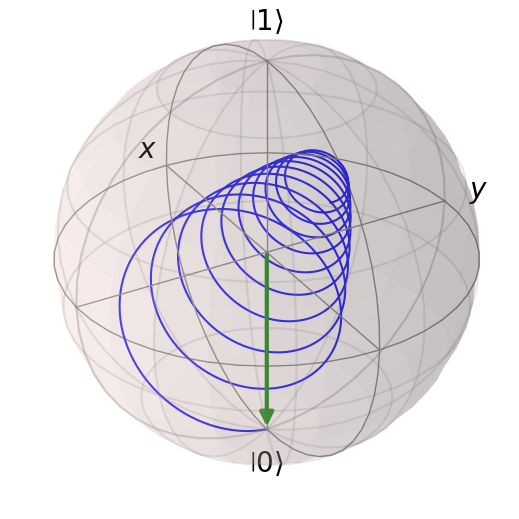

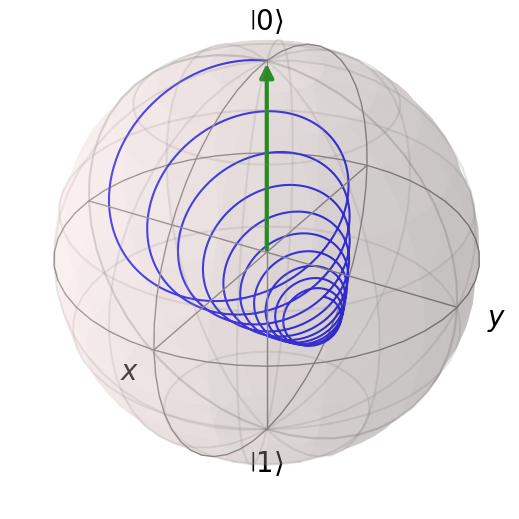

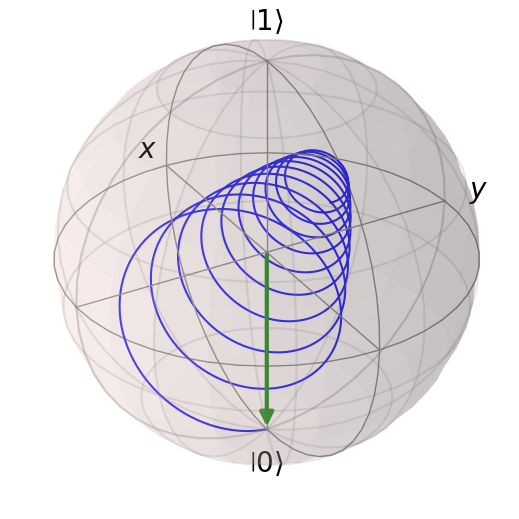

In [70]:
gamma_relax = 0.5
c_ops = [np.sqrt(gamma_relax) * sigmam()]

# solve dynamics
result = mesolve(H, psi0, ts, c_ops, e_ops=[sigmax(), sigmay(), sigmaz()])
exp_sx_relax, exp_sy_relax, exp_sz_relax = result.expect

# Create Bloch sphere plot
sphere = Bloch()
sphere.add_points([exp_sx_relax, exp_sy_relax, exp_sz_relax], meth="l")
sphere.add_states(psi0)
print(sphere.view)
sphere.show()

sphere = Bloch()
sphere.add_points([exp_sx_relax, exp_sy_relax, exp_sz_relax], meth="l")
sphere.add_states(psi0)
# sphere.show()
# sphere.view = [45, 10]
sphere.view = [-60, 210]
sphere.show()
